In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import math


# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Định nghĩa đường dẫn dữ liệu (Sửa theo folder của nhóm)
CURRENT_DIR = os.getcwd()
ROOT_DIR = os.path.dirname(CURRENT_DIR)
ROOT_DIR = os.path.dirname(ROOT_DIR)
DATA_RAW_PATH = os.path.join(ROOT_DIR, "data", 'raw')
PROCESSED_PATH = os.path.join(ROOT_DIR, 'data', 'processed')
print(f"Data path: {DATA_RAW_PATH}")

IMAGES_DIR = os.path.join(ROOT_DIR, 'outputs', 'images')
if not os.path.exists(IMAGES_DIR):
    os.makedirs(IMAGES_DIR)

def load_and_clean_data():
    # 1. Load Master Data
    customers = pd.read_csv(os.path.join(DATA_RAW_PATH, 'customers.csv'))
    geography = pd.read_csv(os.path.join(DATA_RAW_PATH, 'geography.csv'))
    inventory = pd.read_csv(os.path.join(DATA_RAW_PATH, 'inventory.csv'))
    products = pd.read_csv(os.path.join(DATA_RAW_PATH, 'products.csv'))
    promotions = pd.read_csv(os.path.join(DATA_RAW_PATH, 'promotions.csv'))

    # 2. Load Transactional / Supporting Data
    orders = pd.read_csv(os.path.join(DATA_RAW_PATH, 'orders.csv'))
    order_items = pd.read_csv(os.path.join(DATA_RAW_PATH, 'order_items.csv'))
    payments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'payments.csv'))
    returns = pd.read_csv(os.path.join(DATA_RAW_PATH, 'returns.csv'))
    reviews = pd.read_csv(os.path.join(DATA_RAW_PATH, 'reviews.csv'))
    sales = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sales.csv'))
    sample_submission = pd.read_csv(os.path.join(DATA_RAW_PATH, 'sample_submission.csv'))
    shipments = pd.read_csv(os.path.join(DATA_RAW_PATH, 'shipments.csv'))
    web_traffic = pd.read_csv(os.path.join(DATA_RAW_PATH, 'web_traffic.csv'))

    # 3. Ép kiểu datetime cho các cột ngày tháng
    dataframes = {
        'customers': customers,
        'inventory': inventory,
        'orders': orders,
        'promotions': promotions,
        'returns': returns,
        'reviews': reviews,
        'sales': sales,
        'sample_submission': sample_submission,
        'shipments': shipments,
        'web_traffic': web_traffic,
    }

    date_cols = {
        'customers': ['signup_date'],
        'inventory': ['snapshot_date'],
        'orders': ['order_date'],
        'promotions': ['start_date', 'end_date'],
        'returns': ['return_date'],
        'reviews': ['review_date'],
        'sales': ['Date'],
        'sample_submission': ['Date'],
        'shipments': ['ship_date', 'delivery_date'],
        'web_traffic': ['date'],
    }

    for df_name, cols in date_cols.items():
        for col in cols:
            if col in dataframes[df_name].columns:
                dataframes[df_name][col] = pd.to_datetime(dataframes[df_name][col], errors='coerce')

    return (
        customers,
        geography,
        inventory,
        orders,
        order_items,
        payments,
        products,
        promotions,
        returns,
        reviews,
        sales,
        sample_submission,
        shipments,
        web_traffic,
    )

(
    customers_df,
    geography_df,
    inventory_df,
    orders_df,
    order_items_df,
    payments_df,
    products_df,
    promotions_df,
    returns_df,
    reviews_df,
    sales_df,
    sample_submission_df,
    shipments_df,
    web_traffic_df,
) = load_and_clean_data()

: 

# I. product.csv

In [3]:
products_df.head(10)

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.84
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.08,5393.87
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.63,11371.92
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.72,8573.17
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.33,14063.57
5,541,SaigonFlex UC-06,Streetwear,Everyday,M,black,16095.85,15291.06
6,542,SaigonFlex UC-07,Streetwear,Everyday,L,orange,9213.82,6152.07
7,543,SaigonFlex UC-08,Streetwear,Everyday,XL,blue,40.39,22.49
8,544,SaigonFlex UC-09,Streetwear,Everyday,S,white,11334.11,8528.92
9,545,SaigonFlex UC-10,Streetwear,Everyday,M,purple,10045.68,9091.34


In [4]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 150.9+ KB


In [5]:
products_df.columns

Index(['product_id', 'product_name', 'category', 'segment', 'size', 'color',
       'price', 'cogs'],
      dtype='object')

In [6]:
products_df.shape

(2412, 8)

## 1. Tổng quan

### 1.1. Phân tích đơn biến

### 1.1.1. Biến số

#### a. Phân phối và outliers

In [7]:
products_df.columns

Index(['product_id', 'product_name', 'category', 'segment', 'size', 'color',
       'price', 'cogs'],
      dtype='object')

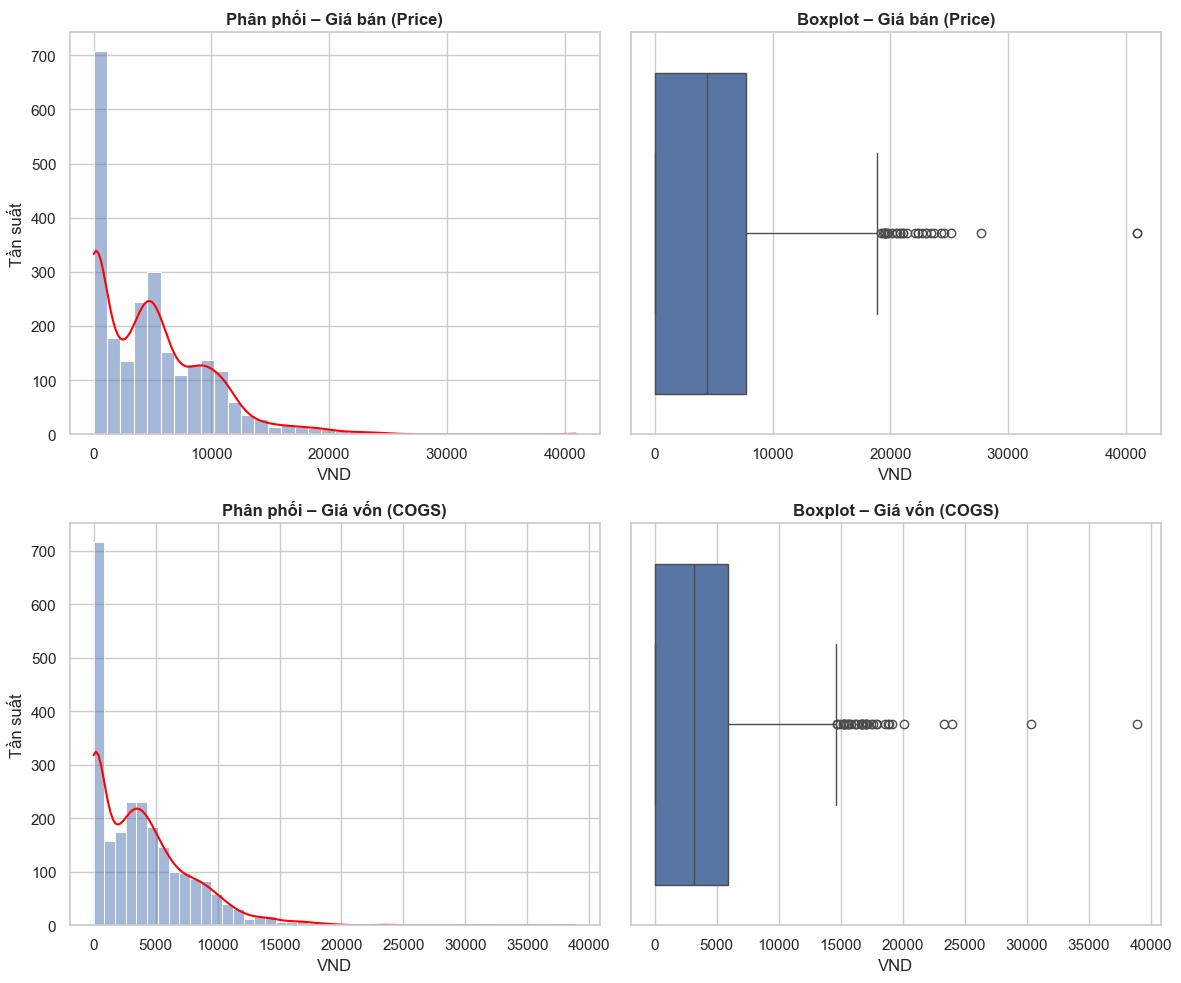

In [15]:
col_config = {
    'price': {'title': 'Giá bán (Price)', 'xlabel': 'VND'},
    'cogs':  {'title': 'Giá vốn (COGS)',  'xlabel': 'VND'}
}

# Danh sách các cột cần vẽ
con_cols_names = ['price', 'cogs']

# Hàm vẽ biểu đồ phân phối (Histogram + KDE) có tính năng lưu ảnh
def plot_distribution(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    # Tự động tính số hàng, cột (grid)
    cols = 2  # Chỉnh thành 2 vì chúng ta chỉ có 2 cột số chính
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(6 * cols, 5 * rows))
    
    for i, col_name in enumerate(con_cols_names, 1):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})
        plt.subplot(rows, cols, i)
        sns.histplot(df[col_name].dropna(), kde=True)
        plt.title(f"Phân phối - {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel("Tần suất")
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ phân phối tại: {save_path}")
        
    plt.show()

# Hàm vẽ kết hợp Distribution và Boxplot có tính năng lưu ảnh
def plot_distribution_boxplot(df, con_cols_names, save_path=None):
    n = len(con_cols_names)
    
    plt.figure(figsize=(12, 5 * n))
    
    for i, col_name in enumerate(con_cols_names):
        cfg = col_config.get(col_name, {'title': col_name, 'xlabel': 'Giá trị'})

        # Distribution plot
        plt.subplot(n, 2, i * 2 + 1)
        ax = sns.histplot(df[col_name].dropna(), kde=True)
        ax.lines[0].set_color('red')
        plt.title(f"Phân phối – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
        plt.ylabel('Tần suất')
        
        # Box plot
        plt.subplot(n, 2, i * 2 + 2)
        sns.boxplot(x=df[col_name].dropna())
        plt.title(f"Boxplot – {cfg['title']}", fontweight='bold')
        plt.xlabel(cfg['xlabel'])
    
    plt.tight_layout()
    
    # Lưu ảnh nếu có đường dẫn
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Đã lưu biểu đồ kết hợp tại: {save_path}")
        
    plt.show()

plot_distribution_boxplot(products_df, con_cols_names)

Nhận xét:

- Quan sát:
  - Phân phối: Cả 2 biến số là Giá bán (Price) và Giá vốn (COGS) đều có phân phối lệch phải (right-skewed) khá mạnh, phần lớn dữ liệu tập trung ở vùng giá trị thấp, trong khi phần đuôi kéo dài về phía các giá trị rất cao.
  - Box plot: Nhìn chung lượng outliers khá nhiều ở cả hai biến, đặc biệt xuất hiện nhiều điểm nằm ngoài whisker bên phải.
  - Chi tiết:
    - Giá bán (Price): Dữ liệu tập trung chủ yếu ở vùng giá thấp đến trung bình, với một đỉnh lớn gần vùng giá rất thấp và thêm một cụm mật độ nữa quanh khoảng vài nghìn VND. Phần đuôi phải kéo dài rất xa, xuất hiện nhiều outliers và có điểm cực trị lên tới khoảng 40,000 VND.
    - Giá vốn (COGS): Phân phối có hình dạng tương tự Giá bán, cũng lệch phải rõ rệt và tập trung phần lớn ở vùng thấp. Mật độ cao nhất nằm ở nhóm giá vốn thấp, sau đó giảm dần nhưng vẫn có đuôi dài và nhiều outliers kéo tới gần 39,000 VND.

- Insights:
  - Dữ liệu sản phẩm chủ yếu nằm ở nhóm giá thấp và trung bình, trong khi chỉ có một số ít sản phẩm thuộc nhóm giá rất cao.
  - Phân phối của Giá bán và Giá vốn có hình dạng khá tương đồng, cho thấy hai biến này biến động cùng cấu trúc và có quan hệ khá chặt chẽ về mặt mức giá.
  - Sự xuất hiện của nhiều outliers ở phía giá trị cao cho thấy tập dữ liệu có thể đang trộn lẫn nhiều phân khúc sản phẩm khác nhau, từ nhóm phổ thông đến nhóm cao cấp.
  - Cần xem xét riêng các điểm giá trị rất cao vì chúng có thể đại diện cho các dòng sản phẩm đặc biệt hoặc làm ảnh hưởng mạnh đến các thống kê trung bình và mô hình hóa sau này.


#### b. Thống kê mô tả

In [9]:
nums_cols = ['price', 'cogs']
products_df[nums_cols].describe()

,price,cogs
count,2412.00,2412.00
mean,4928.22,3868.35
std,4776.74,3878.58
min,9.06,5.18
25%,59.44,35.07
50%,4399.60,3184.93
75%,7720.51,5864.92
max,40950.00,38902.50


### 1.1.2. Biến phân loại (Categorical)

In [ ]:
COL_INFO = {
    'category': {'name': 'Danh mục', 'unit': 'Loại'},
    'segment': {'name': 'Phân khúc', 'unit': 'Nhóm'},
    'size': {'name': 'Kích cỡ', 'unit': 'Size'},
    'color': {'name': 'Màu sắc', 'unit': 'Màu'}
}

# 2. Hàm vẽ biểu đồ phân bố Categorical (Bar chart ngang)
def plot_horizontal_bar_chart(df, cate_cols_names):
    n = len(cate_cols_names)
    cols = 2
    rows = math.ceil(n / cols)

    # Thiết lập kích thước: Tăng chiều ngang để có không gian cho số liệu
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows)) 
    axes = axes.flatten()

    for i, col_name in enumerate(cate_cols_names):
        ax = axes[i]
        
        if col_name in df.columns:
            # Lấy tần suất xuất hiện
            val_counts = df[col_name].value_counts()
            
            # Xử lý: Lấy top 9, nhóm phần còn lại thành 'Khác'
            if len(val_counts) > 10:
                top9 = val_counts.iloc[:9]
                other_sum = val_counts.iloc[9:].sum()
                plot_data = pd.concat([top9, pd.Series({'Khác': other_sum})])
            else:
                plot_data = val_counts
                
            # Đảm bảo index là kiểu chuỗi
            plot_data.index = plot_data.index.astype(str)
            
            # Vẽ Bar chart ngang (Thêm palette cho sinh động)
            sns.barplot(x=plot_data.values, y=plot_data.index, ax=ax)
            
            # Lấy thông tin Tên và Đơn vị từ Từ điển
            info = COL_INFO.get(col_name, {'name': col_name, 'unit': 'Loại'}) 
            
            # Cài đặt tiêu đề và nhãn
            ax.set_title(f"Phân bố - {info['name']}", fontsize=14, fontweight='bold')
            ax.set_xlabel("Số lượng", fontsize=12)
            ax.set_ylabel(f"{info['name']} ({info['unit']})", fontsize=12)
            
            # Thêm con số thực tế bên phải mỗi thanh bar
            for p in ax.patches:
                width = p.get_width()
                if width > 0:
                    ax.annotate(f'{int(width)}', 
                                (width, p.get_y() + p.get_height() / 2.), 
                                ha='left', va='center', fontsize=11, 
                                xytext=(5, 0), textcoords='offset points')
            
            # Mở rộng giới hạn trục x thêm 15% để số liệu (annotate) không bị che khuất
            ax.set_xlim(0, max(plot_data.values) * 1.15)
            
        else:
            ax.set_visible(False)
            
    # Ẩn các trục không sử dụng nếu số lượng cột là số lẻ
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    

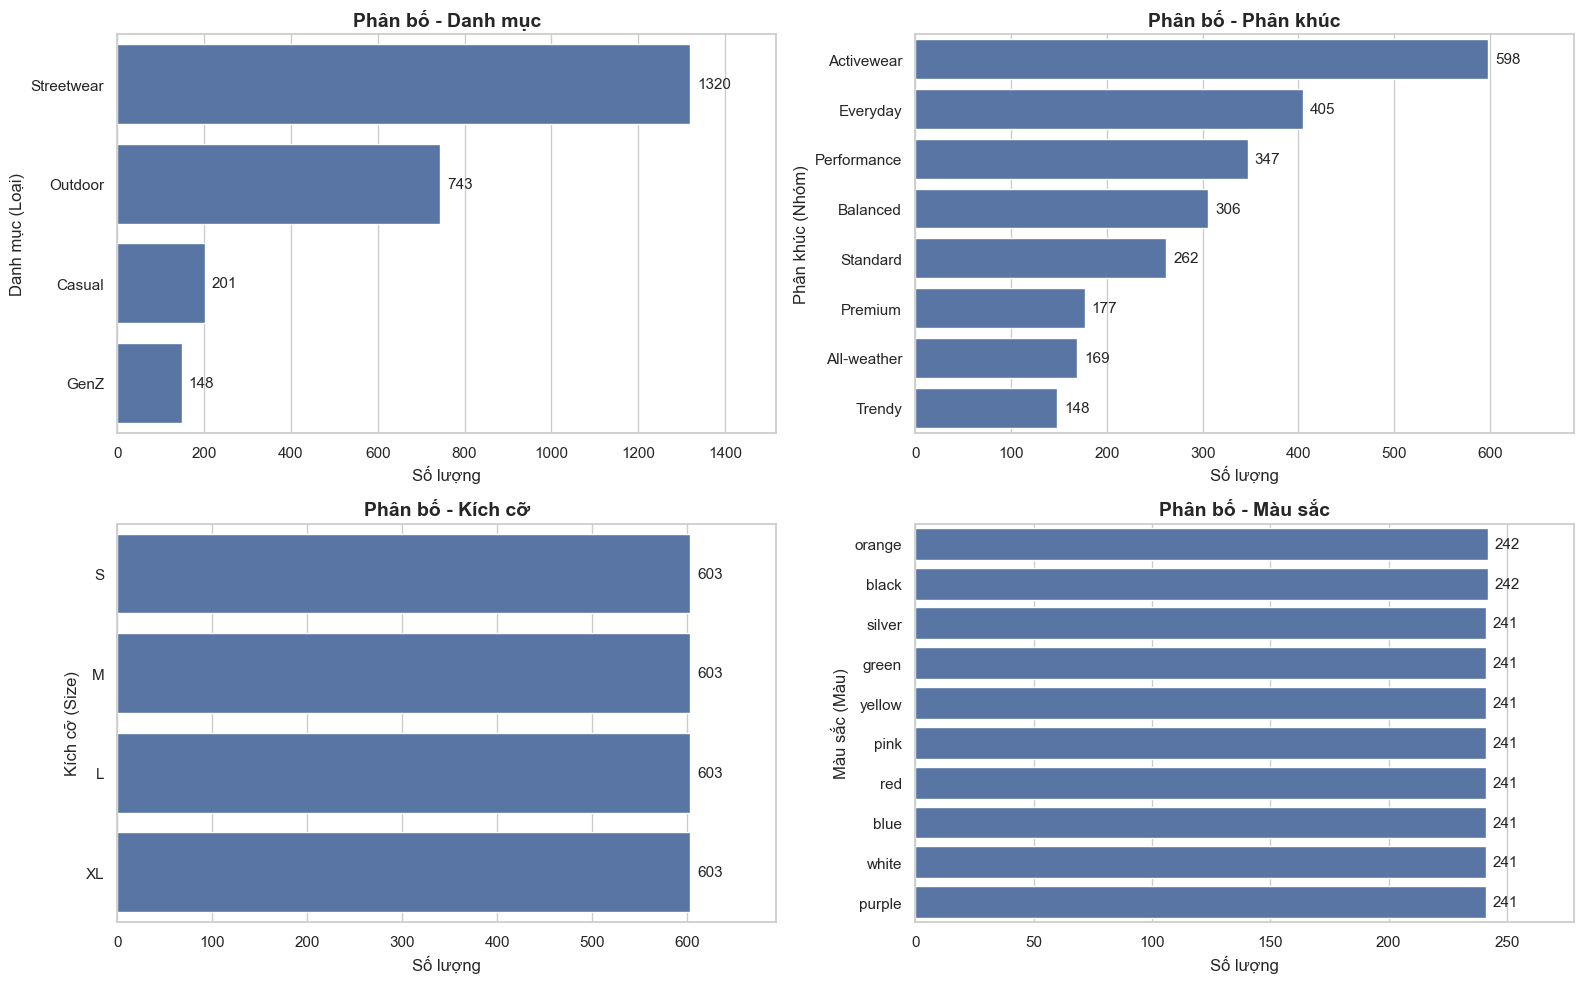

In [11]:
cate_cols = ['category', 'segment', 'size', 'color']
plot_horizontal_bar_chart(products_df, cate_cols)

Nhận xét:

- Quan sát:
  - **Danh mục**: Phân bố không đồng đều, Streetwear chiếm nhiều nhất với 1320 sản phẩm (~54.7%), tiếp theo là Outdoor với 743 sản phẩm (~30.8%). Casual (201, ~8.3%) và GenZ (148, ~6.1%) chiếm tỷ trọng khá nhỏ.
  - **Phân khúc**: Activewear dẫn đầu với 598 sản phẩm (~24.8%), sau đó là Everyday (405, ~16.8%), Performance (347, ~14.4%), Balanced (306, ~12.7%) và Standard (262, ~10.9%). Premium, All-weather và Trendy là các nhóm có quy mô thấp nhất.
  - **Kích cỡ**: 4 size S, M, L, XL có phân bố đồng đều tuyệt đối, mỗi size đều có 603 sản phẩm (25%).
  - **Màu sắc**: 10 màu có phân bố gần như tuyệt đối đồng đều. Orange và black có 242 sản phẩm, các màu còn lại đều ở mức 241 sản phẩm.

- Insights:
  - Danh mục sản phẩm đang tập trung mạnh vào Streetwear và Outdoor, cho thấy định hướng chính của catalog nghiêng về thời trang năng động, ứng dụng hằng ngày và ngoài trời.
  - Casual và GenZ có tỷ trọng khá thấp, nên khi phân tích sâu theo 2 nhóm này cần lưu ý cỡ mẫu nhỏ hơn, dễ làm kết quả dao động hơn các nhóm lớn.
  - Cơ cấu phân khúc đa dạng hơn danh mục, nhưng Activewear vẫn là nhóm nổi bật nhất; đây có thể là phân khúc trọng tâm cần ưu tiên theo dõi về doanh thu, tồn kho hoặc hiệu quả khuyến mãi.
  - Phân bố size đồng đều tuyệt đối cho thấy danh mục được chuẩn hóa rất rõ theo kích cỡ, thuận lợi cho phân tích so sánh giữa các size vì ít bị lệch mẫu.
  - Phân bố màu sắc gần như bằng nhau cho thấy catalog được xây dựng cân bằng giữa các màu, vì vậy từ biểu đồ này chưa thể kết luận màu nào được ưa chuộng hơn, mà chỉ phản ánh cơ cấu danh mục hiện có.
  - Nếu dùng category hoặc segment trong mô hình phân tích/dự báo, cần lưu ý hiện tượng mất cân bằng nhóm ở category và một phần ở segment để tránh bias khi diễn giải kết quả.
